# Testing old and new reference genomes
The [old reference genome](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_002022765.2/) was published in 2017 from an inbred line at the Haskin Shellfish Research Lab at Rutgers with 87x coverage.

The [new reference genome](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/) was published in 2025 from Muscongus Bay Aquaculture and Yale University with 16x coverage.

I've aligned my sequences to both genomes using the same flags/parameters. Now, I'm curious how my choice in reference genome affects my RNA-seq analysis

## 0. load libraries

In [2]:
library(tidyverse)

## 1. load CSVs

In [40]:
newRef.counts <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/processing/qc_outputs/featureCounts_summary_newRef.csv') %>%
mutate(Sample = str_remove(Sample, "\\.bam$")) %>% # remove ".bam" at the end
mutate(Sample = str_remove(Sample, "^counts_")) %>%   # remove "counts_" at start
mutate(ref_genome = 'new') %>%
slice(1:120) # keep only the first 120 rows: seems like i accidentally duplicated rows when generating this csv
head(newRef.counts)

,Sample,Assigned,Unassigned_Unmapped,Unassigned_Read_Type,Unassigned_Singleton,Unassigned_MappingQuality,Unassigned_Chimera,Unassigned_FragmentLength,Unassigned_Duplicate,Unassigned_MultiMapping,Unassigned_Secondary,Unassigned_NonSplit,Unassigned_NoFeatures,Unassigned_Overlapping_Length,Unassigned_Ambiguity,ref_genome
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,B1_B1_O01,42575470,20404042,0,0,0,0,0,0,8764110,0,0,1325055,0,3709262,new
2,B1_Nu_O03,60154873,28795872,0,0,0,0,0,0,13904187,0,0,1844923,0,4995194,new
3,B1_W5_O50,40669850,19026018,0,0,0,0,0,0,10003575,0,0,1164887,0,3535442,new
4,B2_B5_O51,44831889,22358261,0,0,0,0,0,0,10875146,0,0,1308727,0,3798714,new
5,B2_C4_O40,44115239,22923083,0,0,0,0,0,0,15346996,0,0,1391699,0,3789417,new
6,B2_Nu_O12,60625126,30867204,0,0,0,0,0,0,12780841,0,0,1492057,0,4820846,new


In [43]:
oldRef.counts <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/processing/qc_outputs/featureCounts_summary.csv') %>%
mutate(ref_genome = 'old') %>%
mutate(Sample = str_remove(Sample, "^counts_"))   # remove "counts_" at start

head(oldRef.counts)

,Sample,Assigned,Unassigned_Unmapped,Unassigned_Read_Type,Unassigned_Singleton,Unassigned_MappingQuality,Unassigned_Chimera,Unassigned_FragmentLength,Unassigned_Duplicate,Unassigned_MultiMapping,Unassigned_Secondary,Unassigned_NonSplit,Unassigned_NoFeatures,Unassigned_Overlapping_Length,Unassigned_Ambiguity,ref_genome
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,B1_B1_O01,43560302,13364315,0,0,0,0,0,0,17626841,0,0,7292854,0,1315530,old
2,B1_Nu_O03,61112992,18535006,0,0,0,0,0,0,27272204,0,0,10638161,0,1889859,old
3,B1_W5_O50,41697027,12006768,0,0,0,0,0,0,19337191,0,0,7014364,0,1263414,old
4,B2_B5_O51,46515407,13001667,0,0,0,0,0,0,21897610,0,0,8567980,0,1410398,old
5,B2_C4_O40,45537802,13858521,0,0,0,0,0,0,25570278,0,0,9058567,0,1460110,old
6,B2_Nu_O12,62786888,17374948,0,0,0,0,0,0,22900081,0,0,12562764,0,1714702,old


## 2. Check df contents

Double check all samples are in both dfs

In [44]:
dim(newRef.counts) 
dim(oldRef.counts)

sum(newRef.counts$Sample == oldRef.counts$Sample)

[1] 120  16

[1] 120  16

[1] 120

so we have the same samples - good start lol

combining the dfs so that I can plot and look at the difference in assigned and unassigned reads

In [45]:
combo.counts <- rbind(newRef.counts, oldRef.counts)
head(combo.counts)

,Sample,Assigned,Unassigned_Unmapped,Unassigned_Read_Type,Unassigned_Singleton,Unassigned_MappingQuality,Unassigned_Chimera,Unassigned_FragmentLength,Unassigned_Duplicate,Unassigned_MultiMapping,Unassigned_Secondary,Unassigned_NonSplit,Unassigned_NoFeatures,Unassigned_Overlapping_Length,Unassigned_Ambiguity,ref_genome
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,B1_B1_O01,42575470,20404042,0,0,0,0,0,0,8764110,0,0,1325055,0,3709262,new
2,B1_Nu_O03,60154873,28795872,0,0,0,0,0,0,13904187,0,0,1844923,0,4995194,new
3,B1_W5_O50,40669850,19026018,0,0,0,0,0,0,10003575,0,0,1164887,0,3535442,new
4,B2_B5_O51,44831889,22358261,0,0,0,0,0,0,10875146,0,0,1308727,0,3798714,new
5,B2_C4_O40,44115239,22923083,0,0,0,0,0,0,15346996,0,0,1391699,0,3789417,new
6,B2_Nu_O12,60625126,30867204,0,0,0,0,0,0,12780841,0,0,1492057,0,4820846,new


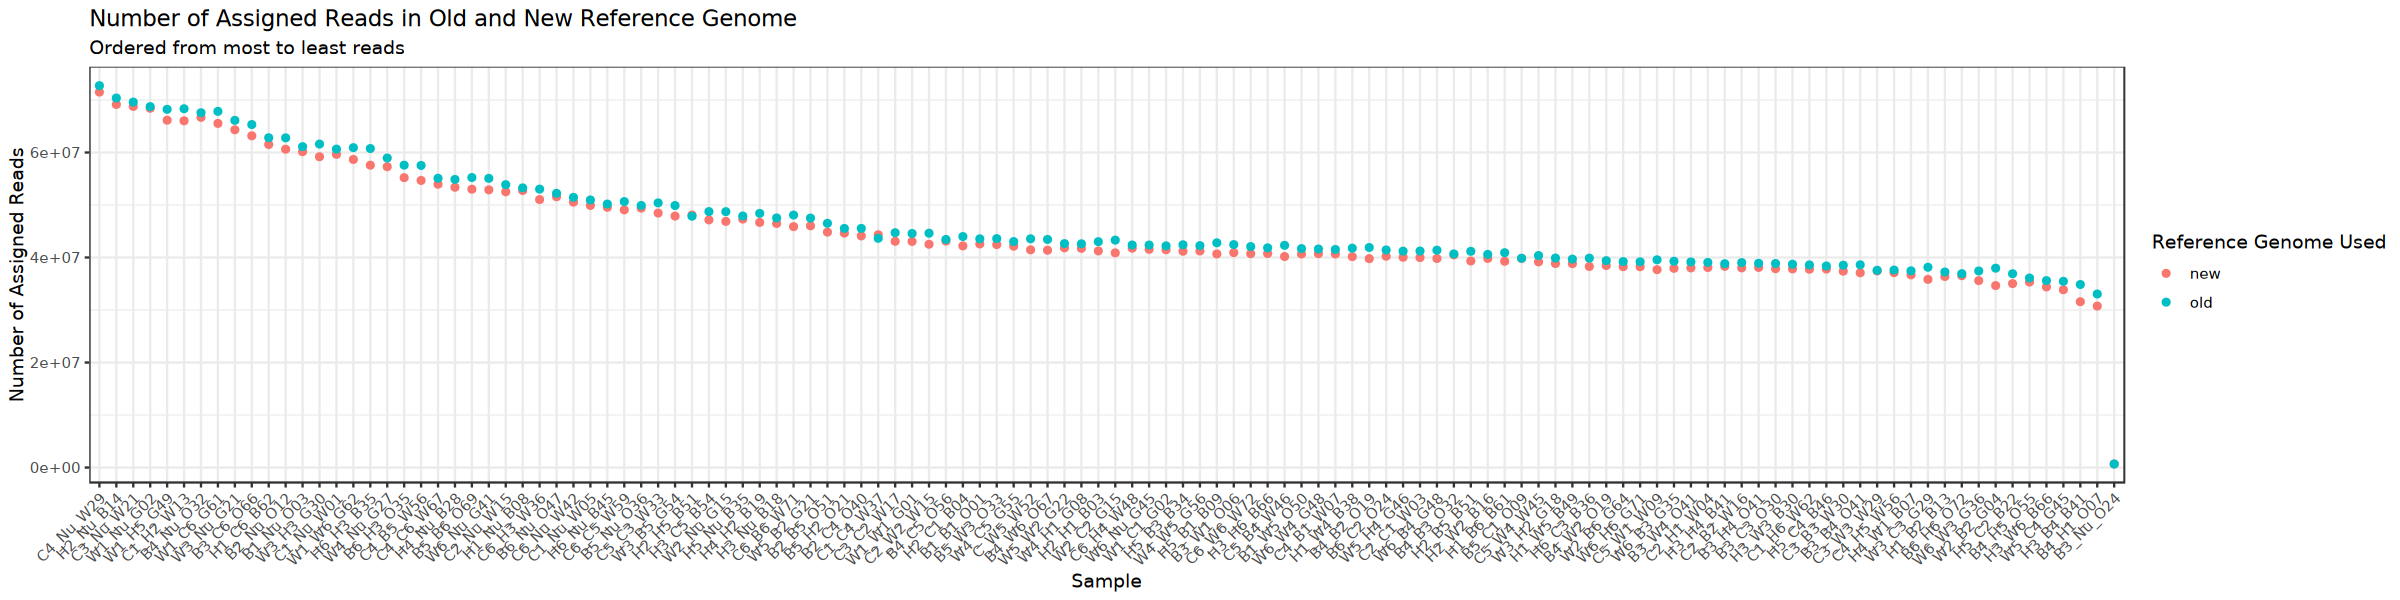

In [58]:
options(repr.plot.width = 20, repr.plot.height = 5)

ggplot(combo.counts, aes(reorder(Sample, -Assigned), y = Assigned, col = ref_genome)) +
geom_point() +
theme_bw() +
labs(title = 'Number of Assigned Reads in Old and New Reference Genome',
    subtitle = 'Ordered from most to least reads',
    x = 'Sample',
    y = 'Number of Assigned Reads',
    col = 'Reference Genome Used') +
# ylim(20000000, 80000000) + # can use this to look more closely at the points by removing outlier
theme(axis.text.x = element_text(angle = 45, hjust = 1))

it appears that the number of assigned reads remains mostly the same for both reference genomes - although aligning with the new reference genome seems to decrease assignment a little, but doesn't appear to be that different or affect one sample more than the other 

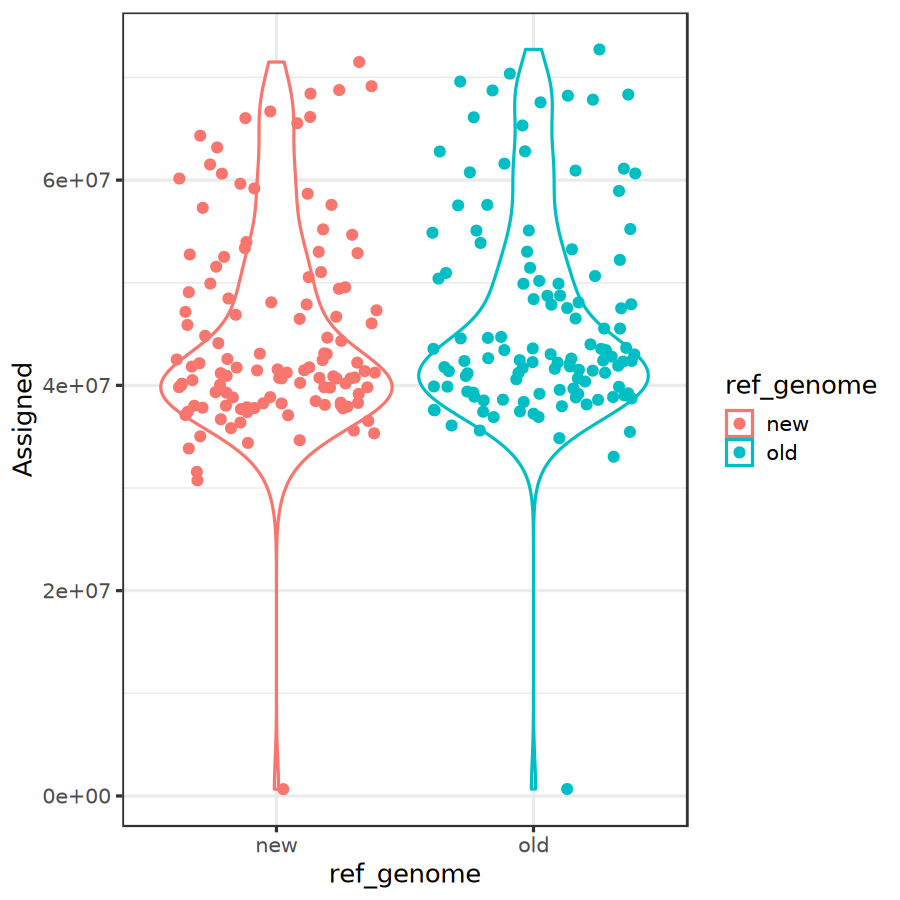

In [60]:
options(repr.plot.width = 7.5, repr.plot.height = 7.5)

ggplot(combo.counts, aes(x=ref_genome, y = Assigned, col = ref_genome)) +
geom_violin() +
geom_jitter() +
theme_bw(base_size = 15) 

appears to be a similar distribution